In [1]:
# TÍTULO: Entrenamiento del Modelo de Detección de Autos (YOLOv8)
# OBJETIVO: Entrenar una red neuronal convolucional utilizando Transfer Learning.

import torch
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import cv2
import glob
import yaml
from datetime import datetime
import pandas as pd

# --- VERIFICACIÓN DE GPU (CRÍTICO PARA TU RTX 4070 Ti) ---
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    print(f"Hardware detectado: {device_name}")
    print(f"   Memoria VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = 0 # ID de la GPU
else:
    print("No se detectó GPU. El entrenamiento será con CPU.")
    device = 'cpu'

# Configuración de Rutas
DATA_YAML = '../../datasets/01_autos/data.yaml'
PROJECT_DIR = '../../models/01_autos' # Donde guardaremos los resultados

PyTorch Version: 2.9.1+cu126
CUDA Available: True
Hardware detectado: NVIDIA GeForce RTX 4070 Ti
   Memoria VRAM: 12.43 GB


In [ ]:
# --- baseline ---
# Ruta donde están los datos originales (sin limpiar)
BASELINE_DATA_PATH = os.path.abspath('../../data/processed/01_autos_original')

# Crear diccionario de configuración
yaml_baseline = {
    'path': BASELINE_DATA_PATH, # Ruta Absoluta
    'train': 'train/images',    # Entrenamiento
    'val': 'val/images',        # Validación
    'test': 'test/images',      # Pruebas
    'names': { 0: 'car' }       # Clases
}

# Guardar el archivo data_baseline.yaml
yaml_path_baseline = os.path.join(BASELINE_DATA_PATH, 'data_baseline.yaml')

with open(yaml_path_baseline, 'w') as f:
    yaml.dump(yaml_baseline, f)

print(f"Configuración Baseline creada en: {yaml_path_baseline}")

Configuración Baseline creada en: /home/roberto/proyecto/data/processed/01_autos_original/data_baseline.yaml


In [ ]:
# --- Entrenamiento baseline ---
print("Entrenamiento baseline (Datos Originales)...")

# Cargar modelo base
model_baseline = YOLO('yolov8n.pt') 

from datetime import datetime
run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_baseline_dataset_tl"

# Entrenar
results_base = model_baseline.train(
    data=yaml_path_baseline,  # Apuntamos al YAML creado en la celda anterior
    project=PROJECT_DIR,      # ../../models/01_autos
    name=run_name,   # Nombre del experimento

    # Hiperparámetros Clave
    epochs=30,             # Máximo de pasadas (100)
    patience=20,            # Si no mejora en 20 épocas, parar (Early Stopping)
    batch=-1,               # AutoBatch (Usa el 90% de tu VRAM automáticamente)
    imgsz=640,              # Resolución de entrada estándar
    
    # Configuración de Hardware
    device=device,
    workers=6,              # Hilos de CPU para cargar datos

    # Gestión de Archivos    
    exist_ok=False,         # No sobrescribir si existe
    pretrained=True,        # Usar pesos de COCO (Transfer Learning)
    optimizer='auto',       # SGD o AdamW (Auto lo elige bien)
    verbose=True,
)

print("Entrenamiento Baseline finalizado.")

Entrenamiento baseline (Datos Originales)...
New https://pypi.org/project/ultralytics/8.3.232 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.229 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11872MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/roberto/proyecto/data/processed/01_autos_original/data_baseline.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

In [ ]:
print("Iniciando validación Baseline en el set de Prueba...")

run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_baseline_dataset_tl"

# Cargar el MEJOR modelo resultante del entrenamiento anterior
best_model_path = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

# Ejecutar validación en split='test'
metrics = best_model.val(split='test', project=PROJECT_DIR, name=f"{run_name}_eval")

print(f"\nResultados Finales en Test del dataset Baseline:")
print(f"   mAP@50:    {metrics.box.map50:.4f} (Precisión holgada)")
print(f"   mAP@50-95: {metrics.box.map:.4f}  (Precisión estricta )")

Iniciando validación Baseline en el set de Prueba...
Ultralytics 8.3.229 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11872MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 246.1±126.4 MB/s, size: 79.2 KB)
val: Scanning /home/roberto/proyecto/data/processed/01_autos_original/test/labels... 1618 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1618/1618 3.7Kit/s 0.4s0.0s
val: New cache created: /home/roberto/proyecto/data/processed/01_autos_original/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 102/102 23.2it/s 4.4s0.0s
                   all       1618       1618      0.999      0.999      0.995      0.958
Speed: 0.4ms preprocess, 0.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/roberto/proyecto/models/01_autos/20251126_v8n_baseline_dataset_eval

Resultados Finales

In [3]:
# --- baseline desde 0 ---
# Ruta donde están los datos originales (sin limpiar)
BASELINE_DATA_PATH = os.path.abspath('../../data/processed/01_autos_original')

# Crear diccionario de configuración
yaml_baseline = {
    'path': BASELINE_DATA_PATH, # Ruta Absoluta
    'train': 'train/images',    # Entrenamiento
    'val': 'val/images',        # Validación
    'test': 'test/images',      # Pruebas
    'names': { 0: 'car' }       # Clases
}

# Guardar el archivo data_baseline.yaml
yaml_path_baseline = os.path.join(BASELINE_DATA_PATH, 'data_baseline.yaml')

with open(yaml_path_baseline, 'w') as f:
    yaml.dump(yaml_baseline, f)

print(f"Configuración Baseline creada en: {yaml_path_baseline}")

Configuración Baseline creada en: /home/roberto/proyecto/data/processed/01_autos_original/data_baseline.yaml


In [ ]:
# --- Entrenamiento baseline desde 0---
print("Entrenamiento baseline (Datos Originales)...")

# Cargar modelo base
model_baseline = YOLO('yolov8n.pt') 

run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_baseline_dataset"

# Entrenar
results_base = model_baseline.train(
    data=yaml_path_baseline,  # Apuntamos al YAML creado en la celda anterior
    project=PROJECT_DIR,      # ../../models/01_autos
    name=run_name,   # Nombre del experimento

    # Hiperparámetros Clave
    epochs=30,             # Máximo de pasadas (100)
    patience=20,            # Si no mejora en 20 épocas, parar (Early Stopping)
    batch=-1,               # AutoBatch (Usa el 90% de tu VRAM automáticamente)
    imgsz=640,              # Resolución de entrada estándar
    
    # Configuración de Hardware
    device=device,
    workers=6,              # Hilos de CPU para cargar datos

    # Gestión de Archivos    
    exist_ok=False,         # No sobrescribir si existe
    pretrained=False,        # Sin pesos
    optimizer='auto',       # SGD o AdamW (Auto lo elige bien)
    verbose=True,
)

print("Entrenamiento Baseline finalizado.")

In [5]:
print("Iniciando validación Baseline sin learning transfer en el set de Prueba...")

run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_baseline_dataset"

# Cargar el MEJOR modelo resultante del entrenamiento anterior
best_model_path = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

# Ejecutar validación en split='test'
metrics = best_model.val(split='test', project=PROJECT_DIR, name=f"{run_name}_eval")

print(f"\nResultados Finales en Test del dataset Baseline:")
print(f"   mAP@50:    {metrics.box.map50:.4f} (Precisión holgada)")
print(f"   mAP@50-95: {metrics.box.map:.4f}  (Precisión estricta )")

Iniciando validación Baseline sin learning transfer en el set de Prueba...
Ultralytics 8.3.229 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11872MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 220.7±110.9 MB/s, size: 39.0 KB)
val: Scanning /home/roberto/proyecto/data/processed/01_autos_original/test/labels.cache... 1618 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1618/1618 4.2Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 102/102 22.7it/s 4.5s.1s
                   all       1618       1618      0.999      0.999      0.995      0.955
Speed: 0.3ms preprocess, 0.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/roberto/proyecto/models/01_autos/20251126_v8n_baseline_dataset_eval

Resultados Finales en Test del dataset Baseline:
   mAP@50:    0.9947 (Precisión holgada)
 

In [4]:
# 1. Cargar modelo base pre-entrenado (Transfer Learning)
# Opciones: yolo11n.pt (rápido), yolo11m.pt (balanceado), yolo11l.pt (preciso)
model_variant = 'yolo11n.pt' 
model_v11n = YOLO(model_variant)

print(f"Modelo cargado: {model_variant}")

# 2. Configurar nombre del experimento (Para tu tesis: FECHA_MODELO_DATASET)
from datetime import datetime
run_name = f"{datetime.now().strftime('%Y%m%d')}_v11n_clean_dataset"

print(f"Los resultados se guardarán en: {PROJECT_DIR}/{run_name}")

Modelo cargado: yolo11n.pt
Los resultados se guardarán en: ../../models/01_autos/20251201_v11n_clean_dataset


In [5]:
# --- INICIAR ENTRENAMIENTO YOLOv11---
results = model_v11n.train(
    data=DATA_YAML,
    
    # Hiperparámetros Clave
    epochs=30,             # Máximo de pasadas (100)
    patience=20,            # Si no mejora en 20 épocas, parar (Early Stopping)
    batch=-1,               # AutoBatch (Usa el 90% de tu VRAM automáticamente)
    imgsz=640,              # Resolución de entrada estándar
    
    # Configuración de Hardware
    device=device,
    workers=6,              # Hilos de CPU para cargar datos
    
    # Gestión de Archivos
    project=PROJECT_DIR,    # Carpeta raíz
    name=run_name,          # Subcarpeta del experimento
    exist_ok=False,         # No sobrescribir si existe
    pretrained=True,        # Usar pesos de COCO (Transfer Learning)
    optimizer='auto',       # SGD o AdamW (Auto lo elige bien)
    verbose=True,
    
    # Aumentación (Opcional: Desactiva HSV si prefieres ser estricto con B&W)
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.4 
)

New https://pypi.org/project/ultralytics/8.3.234 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/01_autos/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=20251201_v11n_clea

In [8]:
print("Iniciando validación con el resplit en el set de Prueba...")

run_name = f"{datetime.now().strftime('%Y%m%d')}_v11n_clean_dataset_tl"

# Cargar el MEJOR modelo resultante del entrenamiento anterior
best_model_path = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

# Ejecutar validación en split='test'
metrics = best_model.val(split='test', project=PROJECT_DIR, name=f"{run_name}_eval")

print(f"\nResultados Finales en Test Set:")
print(f"   mAP@50:    {metrics.box.map50:.4f} (Precisión holgada)")
print(f"   mAP@50-95: {metrics.box.map:.4f}  (Precisión estricta )")

Iniciando validación con el resplit en el set de Prueba...
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2543.1±1544.9 MB/s, size: 46.7 KB)
val: Scanning /home/roberto/moca_proyecto/datasets/01_autos/test/labels.cache... 1615 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1615/1615 4.0Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 22.2it/s 4.6s0.0s
                   all       1615       1615      0.998      0.999      0.995      0.958
Speed: 0.3ms preprocess, 0.8ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/roberto/moca_proyecto/models/01_autos/20251201_v11n_clean_dataset_tl_eval2

Resultados Finales en Test Set:
   mAP@50:    0.9948 (Precisión holgada)
   mAP@50-95: 0.9578  (Precisió

In [ ]:
def obtener_optimizador_real(modelo):
    """
    Recupera el nombre real del optimizador cuando la configuración es 'auto'.
    """
    try:
        # 1. Si el entrenamiento acaba de terminar y el objeto sigue en memoria RAM
        if hasattr(modelo, 'trainer') and modelo.trainer and hasattr(modelo.trainer, 'optimizer'):
            # El optimizador es un objeto (ej. <torch.optim.sgd.SGD object at 0x...>)
            # Obtenemos su nombre de clase real
            opt_obj = modelo.trainer.optimizer
            nombre_real = type(opt_obj).__name__
            
            # También podemos sacar el Learning Rate real final
            lr_final = opt_obj.param_groups[0]['lr']
            
            print(f"Decisión de 'Auto':")
            print(f"   • Optimizador:   {nombre_real}") # Dirá 'SGD' o 'AdamW'
            print(f"   • Learning Rate: {lr_final:.6f}")
            return

        # 2. Si el modelo fue cargado desde disco (.pt) y no hay trainer en memoria
        # Buscamos en los metadatos internos del archivo
        if hasattr(modelo, 'ckpt') and modelo.ckpt:
            train_args = modelo.ckpt.get('train_args', {})
            # A veces aquí también dice 'auto', en cuyo caso la única verdad está en los logs de texto
            print(f"Configuración guardada: {train_args.get('optimizer', 'Desconocido')}")
            print("Si aquí dice 'auto', por favor revisa el archivo '/runs/.../train/main.log'")

    except Exception as e:
        print(f"No se pudo recuperar automáticamente: {e}")

# Ejecutar con tu modelo
obtener_optimizador_real(model_v11n) # O el nombre de tu variable

Decisión de 'Auto':
   • Optimizador:   AdamW
   • Learning Rate: 0.000086


In [15]:
# --- RECUPERAR HIPERPARÁMETROS REALES ---

# 1. Obtener el Batch Size calculado por AutoBatch
# Si usaste batch=-1, aquí verás el número real (ej. 16, 24, 32)

# Esto funciona perfecto con YOLOv11 justo después de entrenar
print(f"Batch Size: {model_v11n.trainer.args.batch}") 
print(f"Optimizer: {obtener_optimizador_real(model_v11n)}")
print(f"Learning Rate inicial: {model_v11n.trainer.args.lr0}")


Batch Size: 14
Decisión de 'Auto':
   • Optimizador:   AdamW
   • Learning Rate: 0.000086
Optimizer: None
Learning Rate inicial: 0.01


In [9]:
# Modelo YOLOv11 con 100 épocas y early stoping de 10. Learning transfer y el dataset limpio.
model_variant = 'yolo11n.pt' 
model_v11n_100 = YOLO(model_variant)

print(f"Modelo cargado: {model_variant}")

# 2. Configurar nombre del experimento (Para tu tesis: FECHA_MODELO_DATASET)
from datetime import datetime
run_name = f"{datetime.now().strftime('%Y%m%d')}_v11n_clean_dataset_100"

print(f"Los resultados se guardarán en: {PROJECT_DIR}/{run_name}")

Modelo cargado: yolo11n.pt
Los resultados se guardarán en: ../../models/01_autos/20251201_v11n_clean_dataset_100


In [16]:
# --- INICIAR ENTRENAMIENTO YOLOv11 POR 100 ÉPOCAS---
results = model_v11n_100.train(
    data=DATA_YAML,
    
    # Hiperparámetros Clave
    epochs=100,             # Máximo de pasadas (100)
    patience=10,            # Si no mejora en 10 épocas, parar (Early Stopping)
    batch=-1,               # AutoBatch (Usa el 90% de tu VRAM automáticamente)
    imgsz=640,              # Resolución de entrada estándar
    
    # Configuración de Hardware
    device=device,
    workers=6,              # Hilos de CPU para cargar datos
    
    # Gestión de Archivos
    project=PROJECT_DIR,    # Carpeta raíz
    name=run_name,          # Subcarpeta del experimento
    exist_ok=False,         # No sobrescribir si existe
    pretrained=True,        # Usar pesos de COCO (Transfer Learning)
    optimizer='auto',       # SGD o AdamW (Auto lo elige bien)
    verbose=True,
    
    # Aumentación (Opcional: Desactiva HSV si prefieres ser estricto con B&W)
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.4 
)

New https://pypi.org/project/ultralytics/8.3.234 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/01_autos/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=20251201_v11n_cle

In [19]:
print("Validación del modelo YOLOv11 entrenado por 100 épocas con learning transfer...")

run_name = f"{datetime.now().strftime('%Y%m%d')}_v11n_clean_dataset_100_tl"

# Cargar el MEJOR modelo resultante del entrenamiento anterior
best_model_path = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

# Ejecutar validación en split='test'
metrics = best_model.val(split='test', project=PROJECT_DIR, name=f"{run_name}_eval")

print(f"\nResultados Finales en Test Set:")
print(f"   mAP@50:    {metrics.box.map50:.4f} (Precisión holgada)")
print(f"   mAP@50-95: {metrics.box.map:.4f}  (Precisión estricta )")

Validación del modelo YOLOv11 entrenado por 100 épocas con learning transfer...
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 530.6±483.6 MB/s, size: 42.3 KB)
val: Scanning /home/roberto/moca_proyecto/datasets/01_autos/test/labels.cache... 1615 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1615/1615 4.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 21.6it/s 4.7s0.0s
                   all       1615       1615      0.998      0.999      0.995      0.961
Speed: 0.3ms preprocess, 0.8ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/roberto/moca_proyecto/models/01_autos/20251201_v11n_clean_dataset_100_tl_eval

Resultados Finales en Test Set:
   mAP@50:    0.9948 (Precisión holgada)
   mAP@50-9

In [20]:
# --- RECUPERAR HIPERPARÁMETROS REALES ---

# 1. Obtener el Batch Size calculado por AutoBatch
print(f"Batch Size: {model_v11n_100.trainer.args.batch}") 
print(f"Optimizer: {obtener_optimizador_real(model_v11n_100)}")
print(f"Learning Rate inicial: {model_v11n_100.trainer.args.lr0}")

Batch Size: 36
Decisión de 'Auto':
   • Optimizador:   SGD
   • Learning Rate: 0.000496
Optimizer: None
Learning Rate inicial: 0.01


In [ ]:
# 1. Cargar modelo base pre-entrenado (Transfer Learning)
# Opciones: yolov8n.pt (rápido), yolov8s.pt, yolov8n.pt (balanceado), yolov8l.pt (preciso)
model_variant = 'yolov8n.pt' 
model = YOLO(model_variant)

print(f"Modelo cargado: {model_variant}")

# 2. Configurar nombre del experimento (Para tu tesis: FECHA_MODELO_DATASET)
from datetime import datetime
run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_clean_dataset"

print(f"Los resultados se guardarán en: {PROJECT_DIR}/{run_name}")

Modelo cargado: yolov8n.pt
Los resultados se guardarán en: ../../models/01_autos/20251126_v8m_clean_dataset


In [26]:
# --- INICIAR ENTRENAMIENTO ---
results = model.train(
    data=DATA_YAML,
    
    # Hiperparámetros Clave
    epochs=30,             # Máximo de pasadas (100)
    patience=20,            # Si no mejora en 20 épocas, parar (Early Stopping)
    batch=-1,               # AutoBatch (Usa el 90% de tu VRAM automáticamente)
    imgsz=640,              # Resolución de entrada estándar
    
    # Configuración de Hardware
    device=device,
    workers=6,              # Hilos de CPU para cargar datos
    
    # Gestión de Archivos
    project=PROJECT_DIR,    # Carpeta raíz
    name=run_name,          # Subcarpeta del experimento
    exist_ok=False,         # No sobrescribir si existe
    pretrained=True,        # Usar pesos de COCO (Transfer Learning)
    optimizer='auto',       # SGD o AdamW (Auto lo elige bien)
    verbose=True,
    
    # Aumentación (Opcional: Desactiva HSV si prefieres ser estricto con B&W)
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.4 
)

New https://pypi.org/project/ultralytics/8.3.232 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.229 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11872MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/01_autos/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=20251126_v8m_clean

In [7]:
print("Iniciando validación con el resplit en el set de Prueba...")

run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_clean_dataset_tl"

# Cargar el MEJOR modelo resultante del entrenamiento anterior
best_model_path = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

# Ejecutar validación en split='test'
metrics = best_model.val(split='test', project=PROJECT_DIR, name=f"{run_name}_eval")

print(f"\nResultados Finales en Test Set:")
print(f"   mAP@50:    {metrics.box.map50:.4f} (Precisión holgada)")
print(f"   mAP@50-95: {metrics.box.map:.4f}  (Precisión estricta )")

Iniciando validación con el resplit en el set de Prueba...
Ultralytics 8.3.229 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11872MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 235.8±106.9 MB/s, size: 69.1 KB)
val: Scanning /home/roberto/proyecto/datasets/01_autos/test/labels... 1615 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1615/1615 3.6Kit/s 0.5s0.1s
val: New cache created: /home/roberto/proyecto/datasets/01_autos/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 23.1it/s 4.4s.1s
                   all       1615       1615      0.998      0.998      0.995       0.96
Speed: 0.4ms preprocess, 0.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/roberto/proyecto/models/01_autos/20251126_v8n_clean_dataset_tl_eval

Resultados Finales en Test Set:
   mAP@50: 

In [ ]:
# 1. Cargar modelo desde cero con únicamente el dataset
# Opciones: yolov8n.pt (rápido), yolov8s.pt, yolov8n.pt (balanceado), yolov8l.pt (preciso)
model_variant = 'yolov8n.pt' 
model_0 = YOLO(model_variant)

print(f"Modelo cargado: {model_variant}")

# 2. Configurar nombre del experimento (Para tu tesis: FECHA_MODELO_DATASET)
from datetime import datetime
run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_clean_dataset"

print(f"Los resultados se guardarán en: {PROJECT_DIR}/{run_name}")

Modelo cargado: yolov8n.pt
Los resultados se guardarán en: ../../models/01_autos/20251126_v8m_clean_dataset


In [7]:
# --- INICIAR ENTRENAMIENTO ---
results = model_0.train(
    data=DATA_YAML,
    
    # Hiperparámetros Clave
    epochs=30,             # Máximo de pasadas (100)
    patience=20,            # Si no mejora en 20 épocas, parar (Early Stopping)
    batch=-1,               # AutoBatch (Usa el 90% de tu VRAM automáticamente)
    imgsz=640,              # Resolución de entrada estándar
    
    # Configuración de Hardware
    device=device,
    workers=6,              # Hilos de CPU para cargar datos
    
    # Gestión de Archivos
    project=PROJECT_DIR,    # Carpeta raíz
    name=run_name,          # Subcarpeta del experimento
    exist_ok=False,         # No sobrescribir si existe
    pretrained=False,        # SIN UTILIZAR PESOS
    optimizer='auto',       # SGD o AdamW (Auto lo elige bien)
    verbose=True,
    
    # Aumentación (Opcional: Desactiva HSV si prefieres ser estricto con B&W)
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.4 
)

Ultralytics 8.3.229 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5771MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/01_autos/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=20251126_v8m_clean_dataset3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [8]:
print("Iniciando validación con el resplit sin pesos en el set de Prueba...")

run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_clean_dataset"

# Cargar el MEJOR modelo resultante del entrenamiento anterior
best_model_path = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

# Ejecutar validación en split='test'
metrics = best_model.val(split='test', project=PROJECT_DIR, name=f"{run_name}_eval")

print(f"\nResultados Finales en Test Set:")
print(f"   mAP@50:    {metrics.box.map50:.4f} (Precisión holgada)")
print(f"   mAP@50-95: {metrics.box.map:.4f}  (Precisión estricta )")

Iniciando validación con el resplit sin pesos en el set de Prueba...
Ultralytics 8.3.229 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11872MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1756.4±1304.8 MB/s, size: 36.4 KB)
val: Scanning /home/roberto/proyecto/datasets/01_autos/test/labels.cache... 1615 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1615/1615 4.1Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 23.0it/s 4.4s.1s
                   all       1615       1615      0.997      0.999      0.995      0.962
Speed: 0.4ms preprocess, 0.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/roberto/proyecto/models/01_autos/20251126_v8n_clean_dataset_eval

Resultados Finales en Test Set:
   mAP@50:    0.9948 (Precisión holgada)
   mAP@50-95: 0.9624  (Precisión estrict

In [ ]:
# Cargar métricas finales de los archivos guardados

# Rutas de los CSV de resultados
base_tl_csv = os.path.join(PROJECT_DIR, '20251126_v8n_baseline_dataset_tl', 'results.csv')
base_csv = os.path.join(PROJECT_DIR, '20251126_v8n_baseline_dataset', 'results.csv')
resplit_tl_csv = os.path.join(PROJECT_DIR, '20251126_v8n_clean_dataset_tl', 'results.csv')
resplit_csv = os.path.join(PROJECT_DIR, '20251126_v8n_clean_dataset', 'results.csv')

def get_best_map(csv_path):
    try:
        df = pd.read_csv(csv_path)
        # Limpiar nombres de columnas (YOLO pone espacios)
        df.columns = [c.strip() for c in df.columns]
        # Devolver el mejor mAP50-95 alcanzado
        return df['metrics/mAP50-95(B)'].max()
    except:
        return 0.0

map_base_tl = get_best_map(base_tl_csv)
map_base = get_best_map(base_csv)
map_resplit_tl = get_best_map(resplit_tl_csv)
map_resplit = get_best_map(resplit_csv)

print(f"\nRESULTADOS COMPARATIVOS (mAP 50-95):\n")
print(f"   - Baseline (Transfer Learning): {map_base_tl:.4f}")
print(f"   - Baseline (Sin pesos): {map_base:.4f}")
delta_base = ((map_base_tl - map_base) / map_base) * 100
print(f"   Mejora relativa:    {delta_base:+.2f}%\n\n")

print(f"   - Resplit (Transfer Learning):  {map_resplit_tl:.4f}")
print(f"   - Resplit (Sin pesos):  {map_resplit:.4f}")
delta_resplit = ((map_resplit_tl - map_resplit) / map_resplit) * 100
print(f"   Mejora relativa:    {delta_resplit:+.2f}%")


RESULTADOS COMPARATIVOS (mAP 50-95):

   - Baseline (Transfer Learning): 0.9580
   - Baseline (Sin pesos): 0.9568
   Mejora relativa:    +0.12%


   - Resplit (Transfer Learning):  0.9545
   - Resplit (Sin pesos):  0.9576
   Mejora relativa:    -0.32%



image 1/1 /home/roberto/proyecto/notebooks/01_autos/../../datasets/01_autos/test/images/007527.jpg: 384x640 1 car, 27.0ms
Speed: 3.0ms preprocess, 27.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


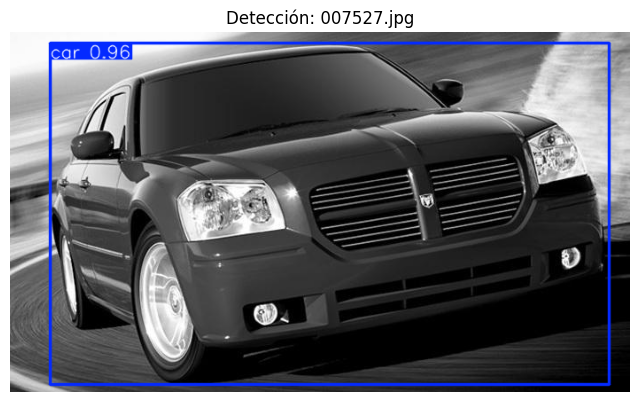


image 1/1 /home/roberto/proyecto/notebooks/01_autos/../../datasets/01_autos/test/images/003986.jpg: 224x640 1 car, 30.7ms
Speed: 1.1ms preprocess, 30.7ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 640)


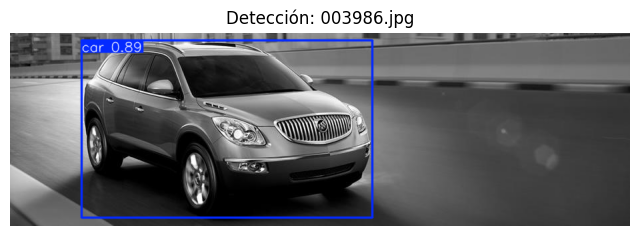


image 1/1 /home/roberto/proyecto/notebooks/01_autos/../../datasets/01_autos/test/images/014818.jpg: 480x640 1 car, 37.3ms
Speed: 1.8ms preprocess, 37.3ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


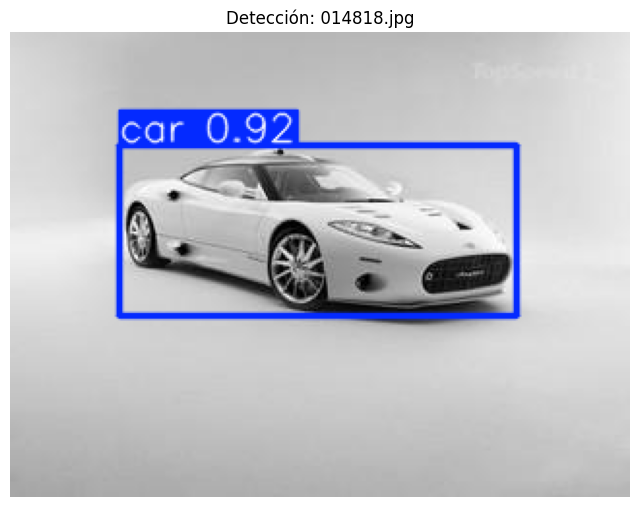


image 1/1 /home/roberto/proyecto/notebooks/01_autos/../../datasets/01_autos/test/images/012190.jpg: 416x640 1 car, 32.3ms
Speed: 1.7ms preprocess, 32.3ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)


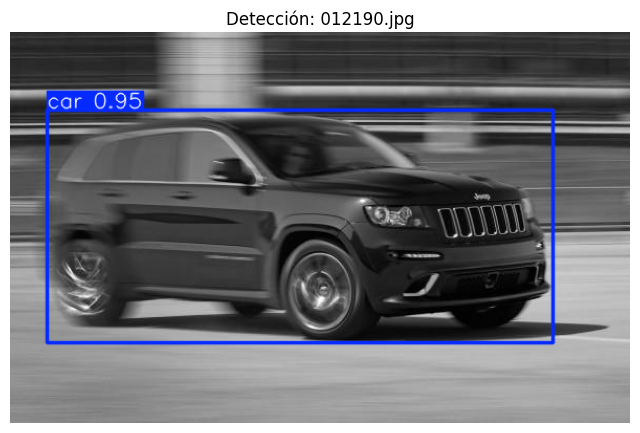

In [7]:
# Obtener imágenes del set de test para predecir

# Cargar el MEJOR modelo resultante del entrenamiento anterior
run_name = f"{datetime.now().strftime('%Y%m%d')}_v8n_baseline_dataset_tl"
best_model_path = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

test_images = glob.glob('../../datasets/01_autos/test/images/*.jpg')[:4] # Tomamos 4 ejemplos

for img_path in test_images:
    # Inferencia
    results = best_model.predict(img_path, conf=0.5)
    
    # Mostrar
    for r in results:
        im_array = r.plot()  # r.plot() dibuja las cajas en la imagen numpy
        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Detección: {os.path.basename(img_path)}")
        plt.show()

In [4]:
import shutil
import os

name = f"20251126_v8n_clean_dataset_tl"
best_model_path = os.path.join(PROJECT_DIR, name, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

PRODUCTION_PATH = '../../production_weights'
os.makedirs(PRODUCTION_PATH, exist_ok=True)

# Copiar y renombrar
target_path = os.path.join(PRODUCTION_PATH, '01_autos_best.pt')
shutil.copy(best_model_path, target_path)

print(f"Modelo exportado exitosamente a: {target_path}")
print("   Este archivo está listo para ser usado por el Pipeline de Placas.")

Modelo exportado exitosamente a: ../../production_weights/01_autos_best.pt
   Este archivo está listo para ser usado por el Pipeline de Placas.
